# Modelado de las series S0 y S5

## Resumen técnico

Se evaluaron **S0 — Total mensual** y **S5 — Estados Unidos** con la misma
partición temporal: 147 meses de entrenamiento y 63 de prueba. En S0,
**Prophet** obtuvo el menor RMSE
(139,549 viajeros); en S5, el menor error correspondió a
**ARIMA(1,1,1)** (26,794 viajeros).

Estos resultados deben leerse con cautela. El conjunto de prueba comienza en
abril de 2021, justo durante la recuperación posterior al cierre pandémico.
Los modelos aprendieron principalmente del comportamiento anterior a la
pandemia y, por ello, tienden a quedarse por debajo del nivel observado entre
2022 y 2026. “Mejor modelo” significa el menor error dentro de los candidatos
probados, no un pronóstico preciso en términos absolutos.

## Contexto y métodos

### Supuestos principales

- Las series tienen frecuencia mensual (`MS`) y período estacional de 12.
- El entrenamiento cubre enero de 2009 a marzo de 2021.
- La prueba cubre abril de 2021 a junio de 2026.
- Las transformaciones, parámetros y ajustes solo usan entrenamiento.
- MAE y RMSE comparan todos los modelos sobre los mismos 63 meses.
- AIC y BIC se reportan únicamente para ARIMA/SARIMA.
- MAPE excluye meses cuyo valor real sea cero; en estas pruebas no hay ceros.

Se comparan candidatos ARIMA/SARIMA manuales, la sugerencia acotada de
`auto_arima`, Prophet, Holt-Winters, suavizamiento exponencial simple y
Seasonal Naive. El objetivo no es ocultar los modelos que fallan: un candidato
inestable permanece en la tabla para mostrar por qué fue descartado.

In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import Image, display

RAIZ = Path.cwd().resolve()
if RAIZ.name == "notebooks":
    RAIZ = RAIZ.parent
sys.path.insert(0, str(RAIZ / "src"))

from modelado_s0_s5 import ejecutar_modelado_s0_s5

resultados = ejecutar_modelado_s0_s5(guardar=True, generar_figuras=True)
metricas = pd.read_csv(RAIZ / "data" / "processed" / "resultados" / "metricas_s0_s5.csv")
estacionariedad = pd.read_csv(
    RAIZ / "data" / "processed" / "resultados" / "estacionariedad_s0_s5.csv"
)
DIR_IMG = RAIZ / "informe" / "img" / "final"

validacion = pd.DataFrame({
    "serie": ["S0", "S5"],
    "meses_total": [
        len(resultados["S0_total"]["serie"]),
        len(resultados["S5_estados_unidos"]["serie"]),
    ],
    "meses_train": [
        len(resultados["S0_total"]["train"]),
        len(resultados["S5_estados_unidos"]["train"]),
    ],
    "meses_test": [
        len(resultados["S0_total"]["test"]),
        len(resultados["S5_estados_unidos"]["test"]),
    ],
    "pronosticos_por_modelo": [
        len(resultados["S0_total"]["test"]),
        len(resultados["S5_estados_unidos"]["test"]),
    ],
})
validacion

Importing plotly failed. Interactive plots will not work.


17:06:31 - cmdstanpy - INFO - Chain [1] start processing


17:06:31 - cmdstanpy - INFO - Chain [1] done processing


,serie,meses_total,meses_train,meses_test,pronosticos_por_modelo
0,S0,210,147,63,63
1,S5,210,147,63,63


## S0 — Total mensual

S0 contiene 210 meses, desde enero de 2009 hasta junio de 2026. La
descomposición del entrenamiento muestra una tendencia fuerte
(0.821) y una estacionalidad moderada
(0.467). La caída de 2020 es un cambio extraordinario
de nivel y no debe confundirse con la estacionalidad normal de la serie.

### La partición deja la recuperación casi completa dentro de la prueba

La franja amarilla ubica la pandemia y la línea roja marca el inicio del
conjunto de prueba. Esto permite ver por qué el ejercicio es exigente: el
modelo debe pronosticar una recuperación que apenas había comenzado al cerrar
el entrenamiento.

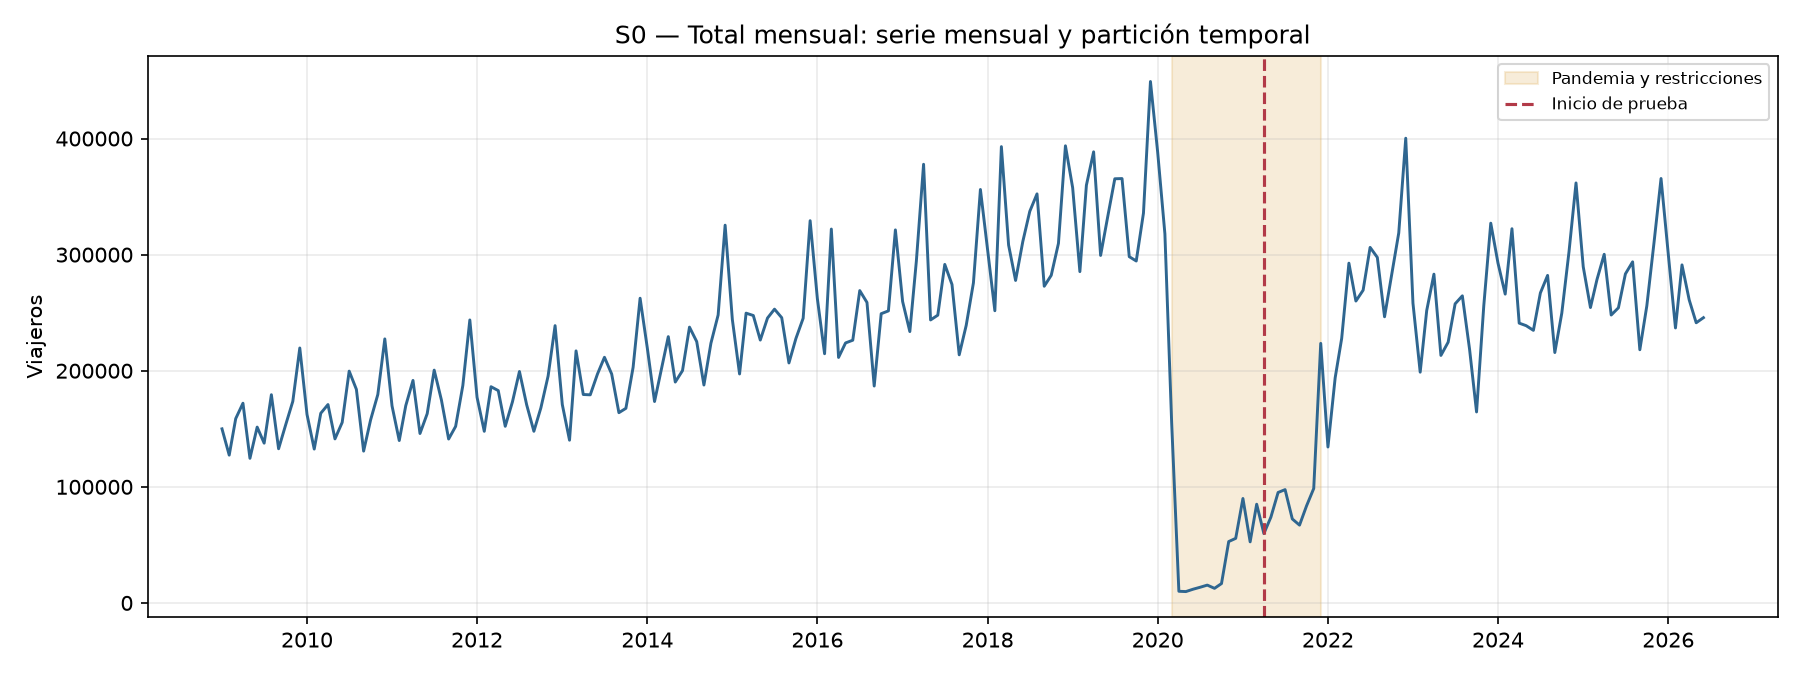

In [2]:
display(Image(filename=str(DIR_IMG / "s0_serie_particion.png")))

### La tendencia domina, aunque existe un patrón mensual reconocible

La fuerza de tendencia de 0.821 supera la fuerza
estacional de 0.467. En términos sencillos, antes de
la pandemia el total venía creciendo y, sobre ese crecimiento, aparecían
meses altos y bajos que se repetían. El residuo aumenta alrededor del choque
pandémico porque la descomposición aditiva no fue diseñada para explicar un
cierre tan abrupto.

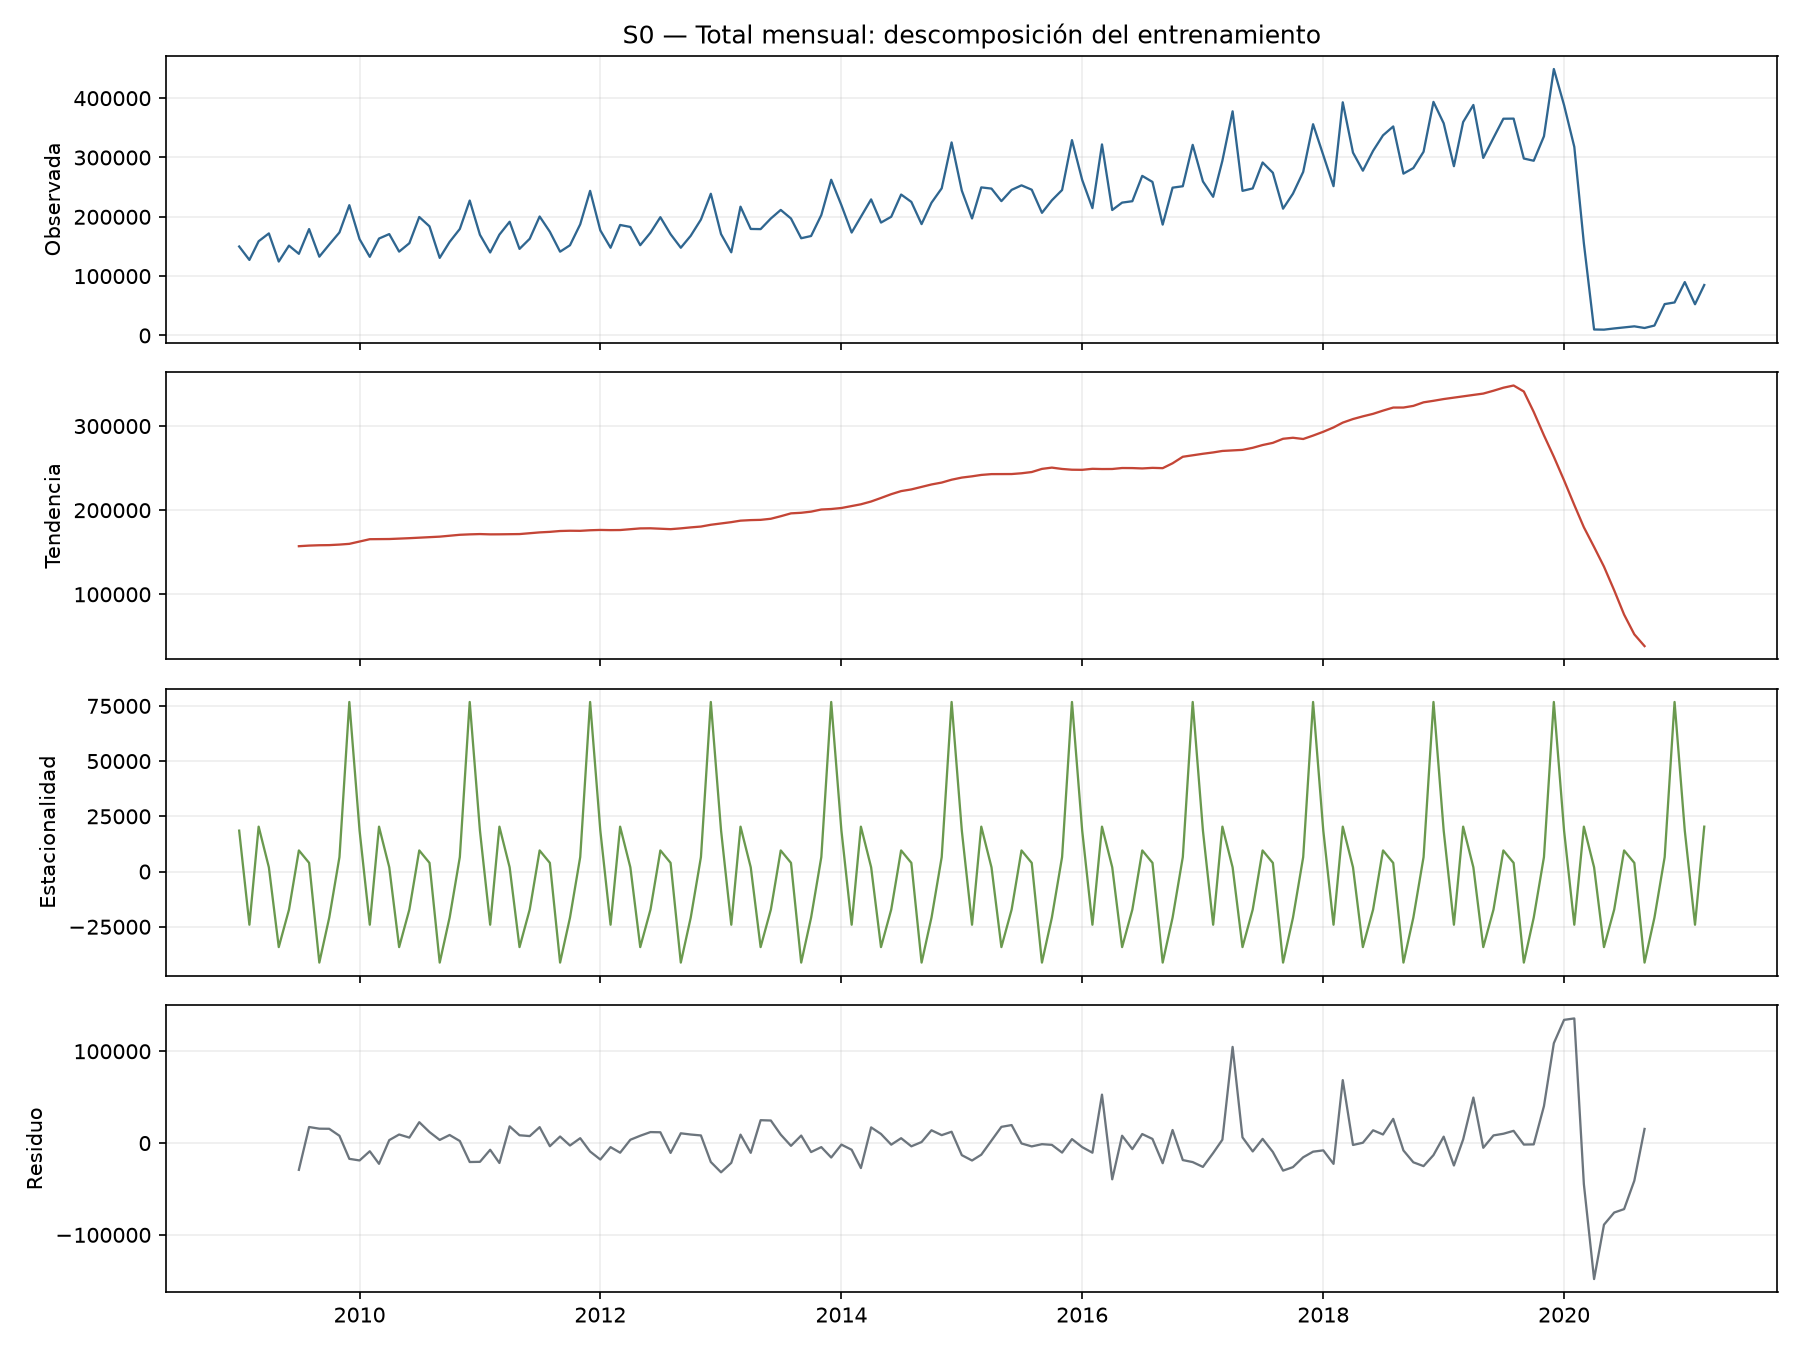

In [3]:
display(Image(filename=str(DIR_IMG / "s0_descomposicion.png")))

### La escala logarítmica ayuda a comparar cambios relativos

S0 es estrictamente positiva, por lo que se utiliza logaritmo. La
transformación reduce el peso de los meses con volúmenes muy altos y hace más
comparable la variación a lo largo del tiempo. Aun así, ninguna transformación
elimina el quiebre extraordinario de 2020.

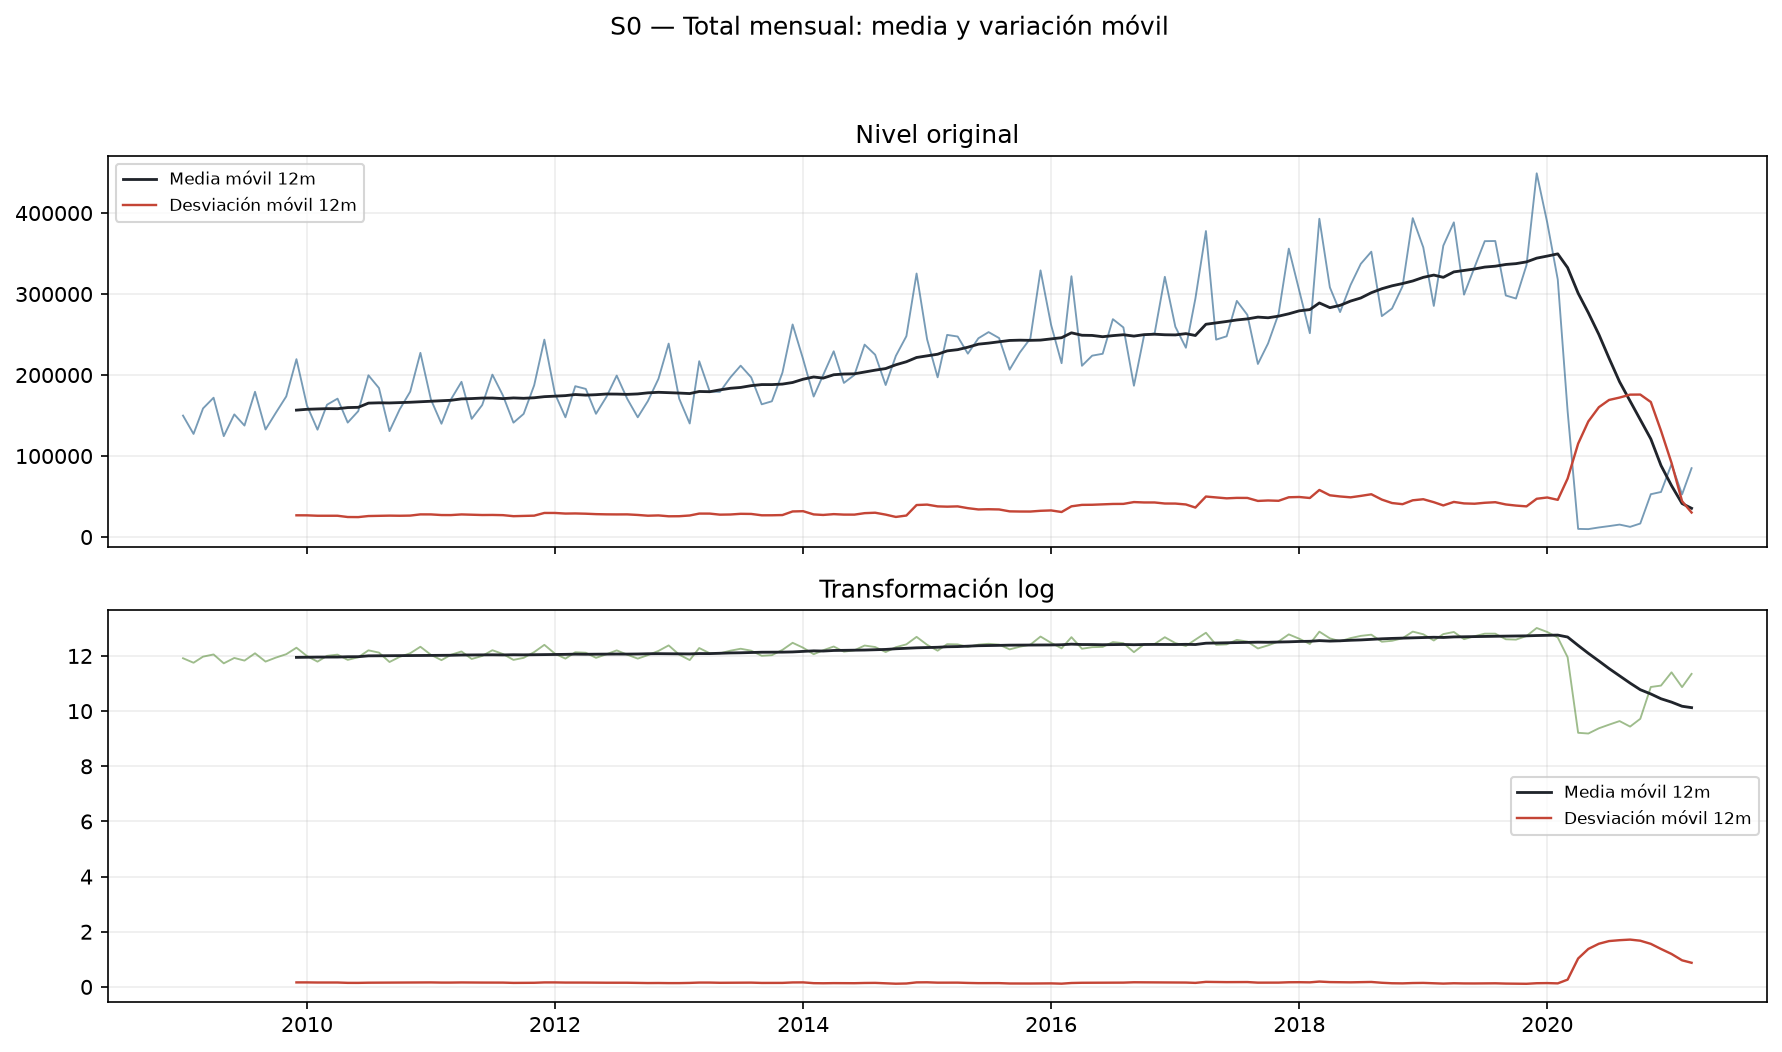

In [4]:
display(Image(filename=str(DIR_IMG / "s0_varianza.png")))

### Las pruebas apoyan una diferencia regular y permiten revisar la estacional

En logaritmo sin diferenciar, ADF no rechaza la raíz unitaria. Con `d=1`,
ADF y KPSS coinciden en estacionariedad. También se probó `D=1` porque la ACF
mantiene señales en rezagos estacionales; la combinación se usa en dos
candidatos SARIMA para comparar, no como una decisión automática.

,transformacion,p_ADF,p_KPSS,veredicto
0,Nivel,0.1520,0.0763,"resultado mixto: KPSS dice estacionaria, ADF no"
1,log,0.1156,0.1000,"resultado mixto: KPSS dice estacionaria, ADF no"
2,log + d=1,0.0277,0.1000,estacionaria (ambas pruebas coinciden)
3,log + D=1,0.9636,0.0294,NO estacionaria (ambas pruebas coinciden)
4,log + d=1 + D=1,0.0000,0.1000,estacionaria (ambas pruebas coinciden)


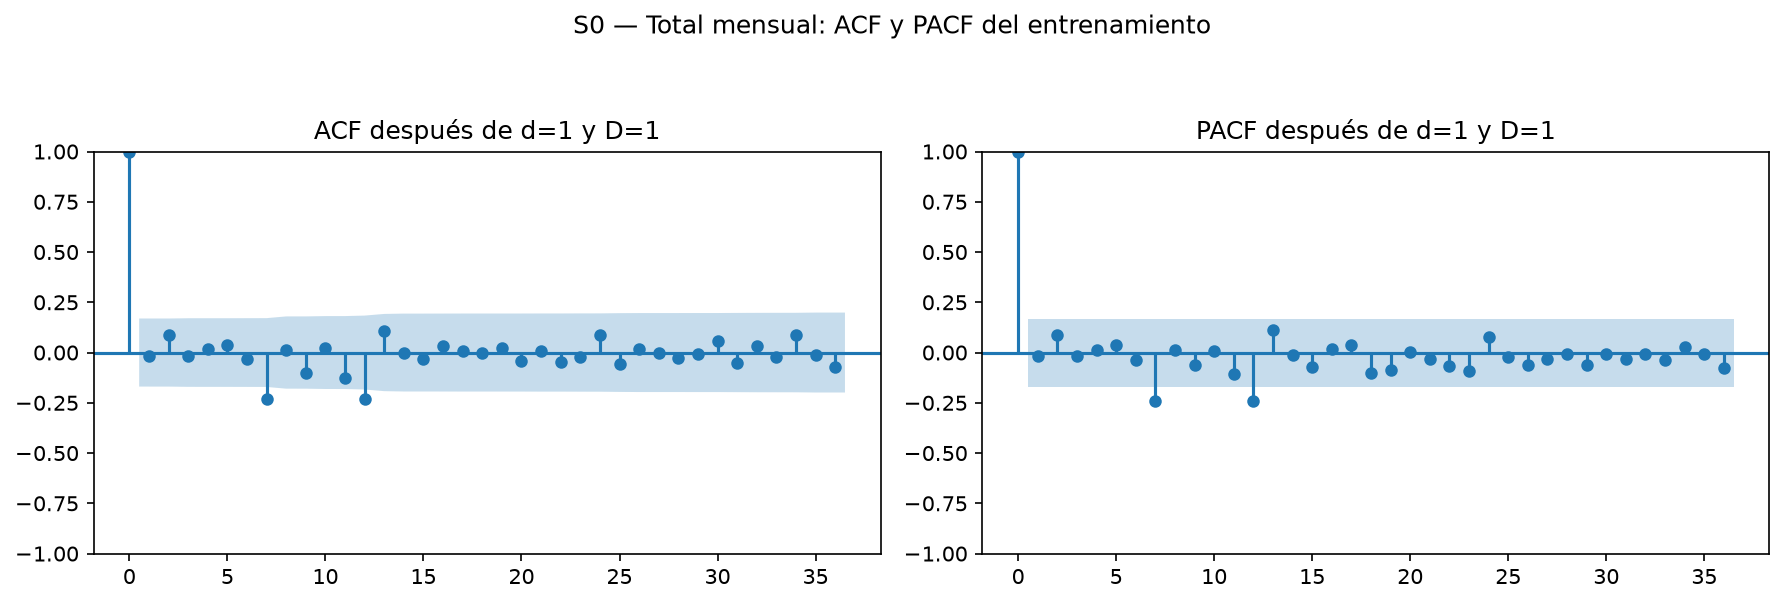

In [5]:
display(
    estacionariedad.loc[
        estacionariedad["serie"] == "S0_total",
        ["transformacion", "p_ADF", "p_KPSS", "veredicto"],
    ].round(4)
)
display(Image(filename=str(DIR_IMG / "s0_acf_pacf.png")))

### Prophet obtiene el menor error, pero todavía subestima la recuperación

El mejor resultado de S0 fue Prophet, con
MAE de 132,305 y RMSE de
139,549 viajeros. Su MAPE fue
60.9%, por lo que el error sigue siendo alto. La gráfica
muestra que incluso el mejor candidato queda por debajo de muchos valores
observados desde 2022.

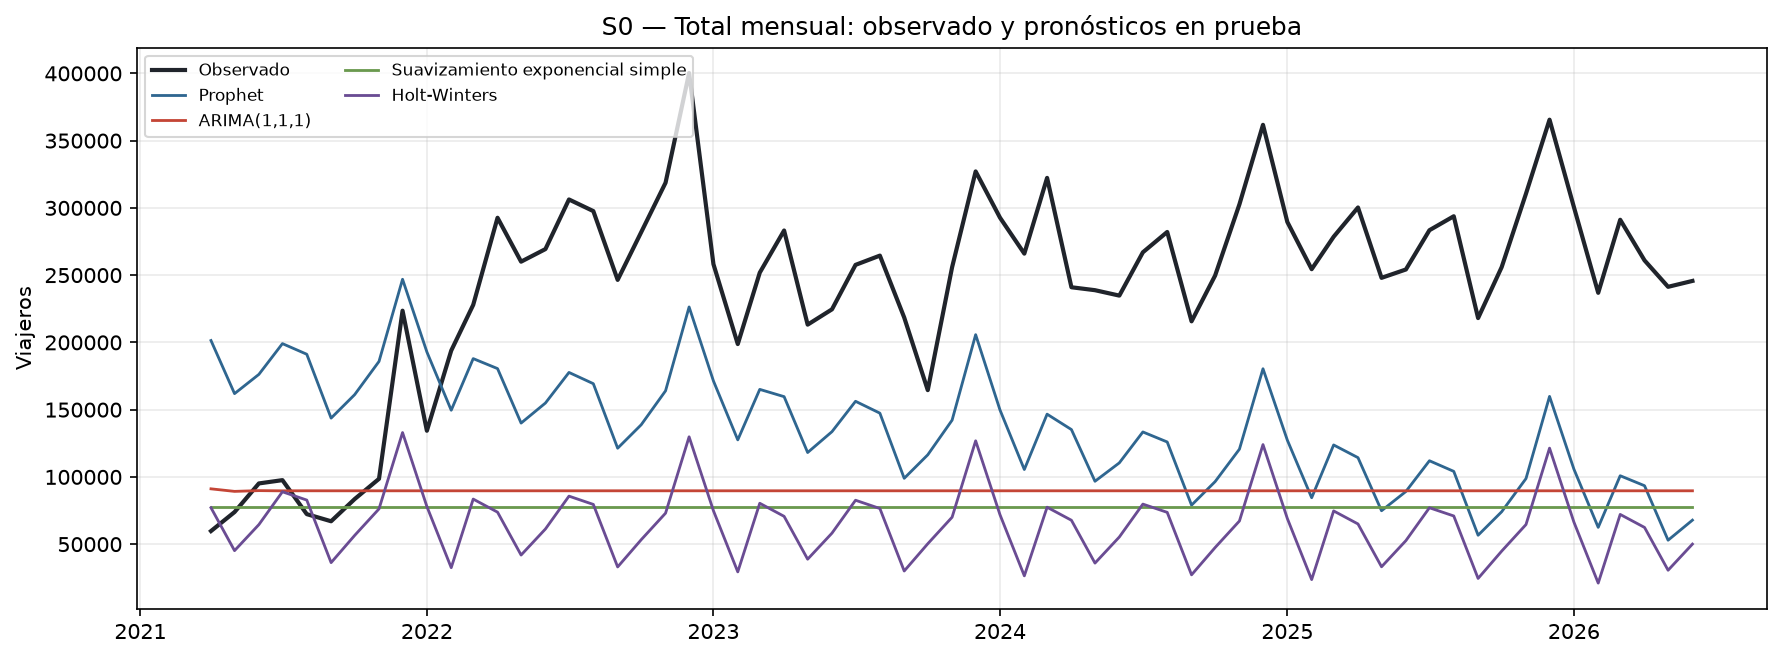

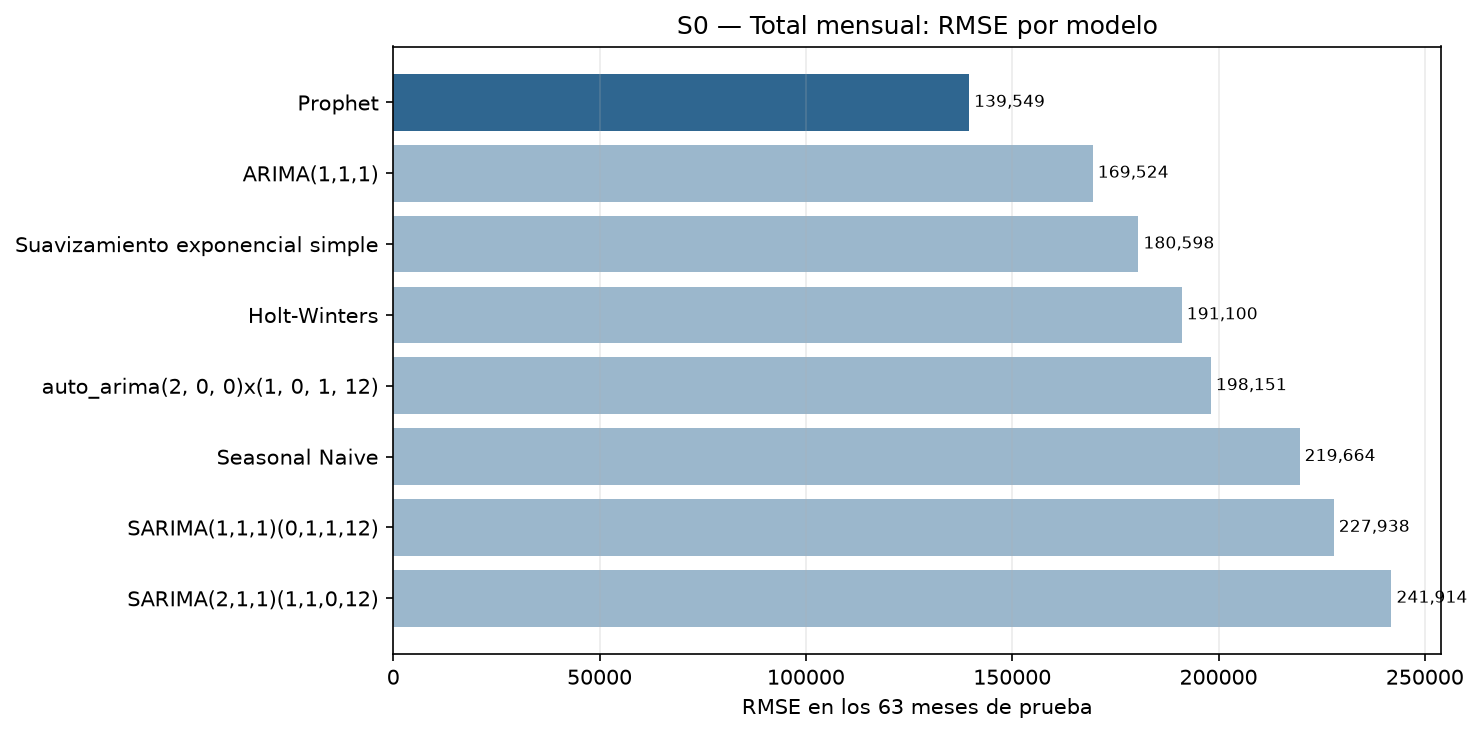

,serie,modelo,parametros,transformacion,AIC,BIC,MAE,RMSE,MAPE,Ljung_Box_p,mejor_modelo
0,S0_total,Prophet,"{'estacionalidad_anual': True, 'modo_estaciona...",ninguna,NaN,NaN,132304.63,139548.95,60.89,0.0000,True
1,S0_total,"ARIMA(1,1,1)","{'orden': (1, 1, 1), 'orden_estacional': (0, 0...",log,92.36,101.27,154872.62,169524.19,59.30,0.0824,False
2,S0_total,Suavizamiento exponencial simple,"{'tendencia': None, 'estacionalidad': None}",ninguna,NaN,NaN,165372.54,180598.23,62.91,0.0000,False
3,S0_total,Holt-Winters,"{'tendencia': 'aditiva amortiguada', 'estacion...",ninguna,NaN,NaN,178161.74,191100.17,69.82,0.7874,False
4,S0_total,"auto_arima(2, 0, 0)x(1, 0, 1, 12)","{'orden': (2, 0, 0), 'orden_estacional': (1, 0...",log,66.50,80.96,183942.73,198150.74,72.25,0.2768,False
5,S0_total,Seasonal Naive,{'rezago': 12},ninguna,NaN,NaN,207321.64,219663.87,84.91,0.0000,False
6,S0_total,"SARIMA(1,1,1)(0,1,1,12)","{'orden': (1, 1, 1), 'orden_estacional': (0, 1...",log,70.45,81.60,213008.13,227938.34,84.09,0.2341,False
7,S0_total,"SARIMA(2,1,1)(1,1,0,12)","{'orden': (2, 1, 1), 'orden_estacional': (1, 1...",log,62.80,76.74,222189.54,241913.93,84.57,0.4112,False


In [6]:
display(Image(filename=str(DIR_IMG / "s0_pronosticos.png")))
display(Image(filename=str(DIR_IMG / "s0_rmse_modelos.png")))
display(
    metricas.loc[metricas["serie"] == "S0_total"].round({
        "AIC": 2, "BIC": 2, "MAE": 2, "RMSE": 2,
        "MAPE": 2, "Ljung_Box_p": 4,
    })
)

### El diagnóstico obliga a mantener una advertencia

Aunque Prophet presenta el menor RMSE, sus residuos conservan
autocorrelación (Ljung-Box p≈0.0000). Esto significa que todavía queda
estructura temporal sin explicar. Entre los candidatos ARIMA, ARIMA(1,1,1)
presenta residuos más cercanos a ruido blanco, pero su error fuera de muestra
es mayor. Por eso la selección final de S0 se hace por RMSE y se acompaña de
esta limitación, en vez de afirmar que el ajuste es completamente adecuado.

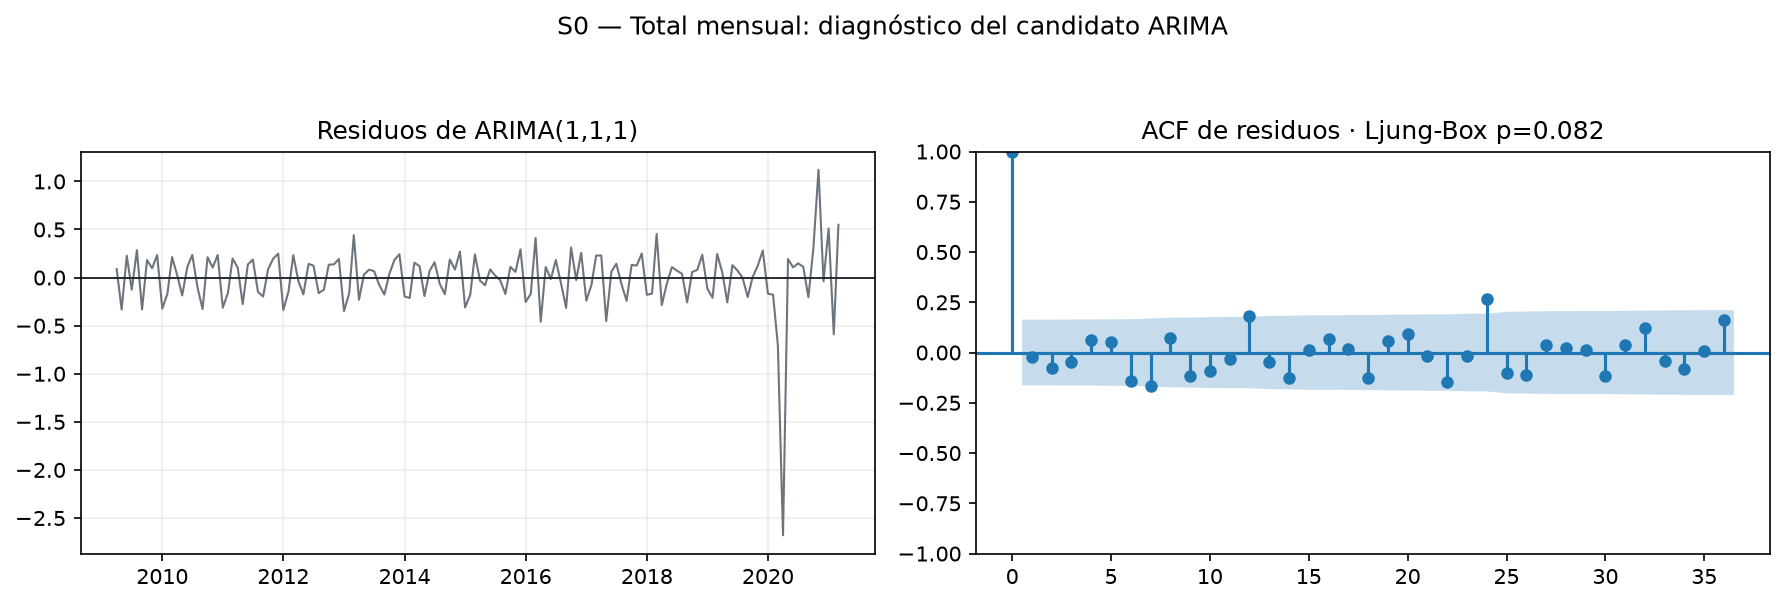

In [7]:
display(Image(filename=str(DIR_IMG / "s0_residuos.png")))

## S5 — Estados Unidos

S5 también contiene 210 meses. Su entrenamiento tiene cinco meses en cero,
entre abril y agosto de 2020, por lo que el logaritmo convencional no es
válido; se utiliza `log1p`. La serie combina una tendencia marcada
(0.709) con una estacionalidad también fuerte
(0.704).

### La recuperación supera claramente el nivel aprendido antes del corte

Después de los ceros de 2020, la serie se recupera y alcanza niveles superiores
a los observados en buena parte del entrenamiento. La línea de corte vuelve a
dejar el cambio de régimen dentro de la prueba, de modo que los pronósticos
basados en el pasado quedan sistemáticamente bajos.

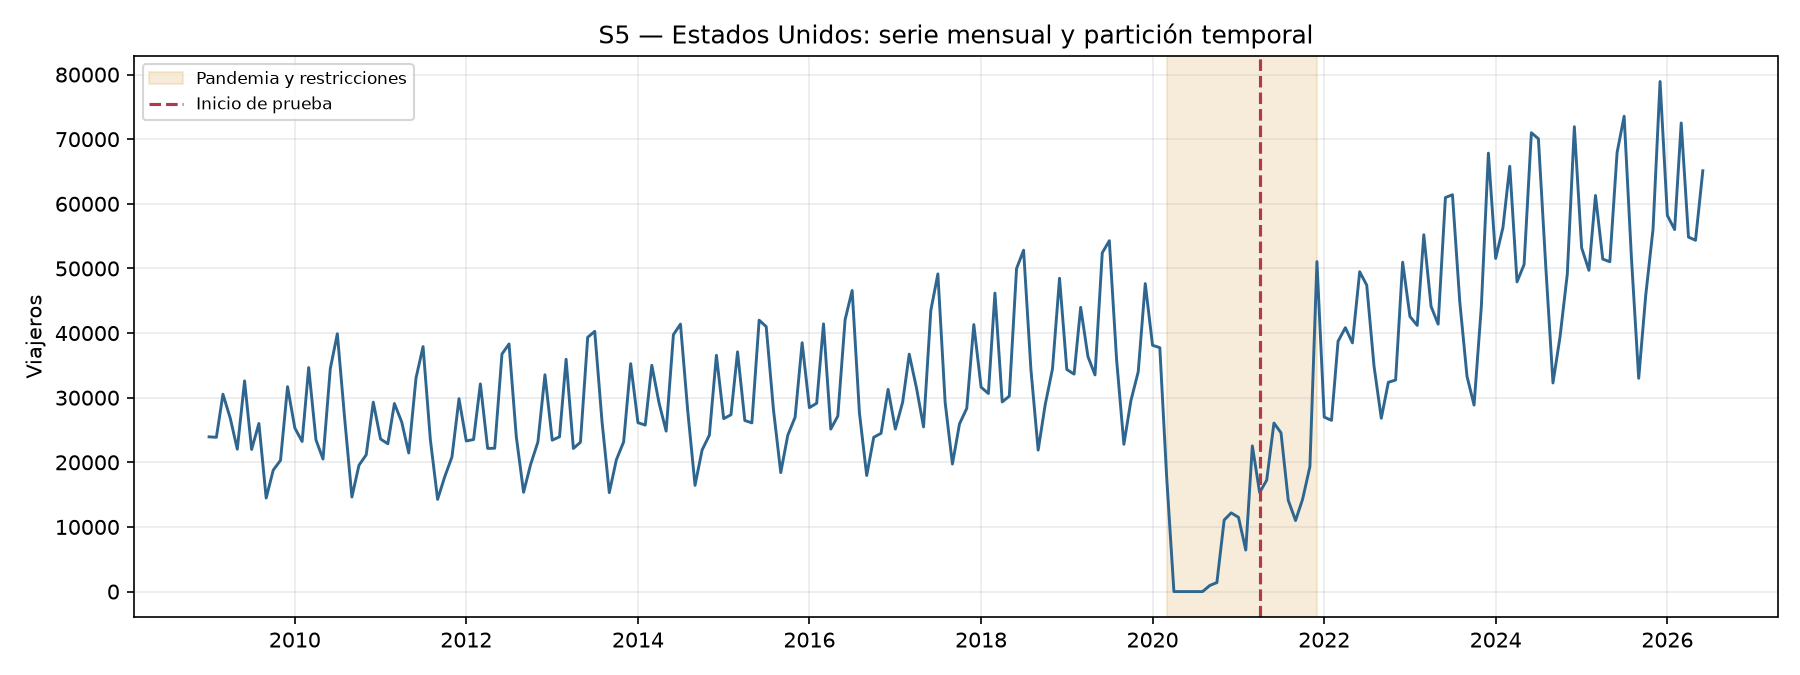

In [8]:
display(Image(filename=str(DIR_IMG / "s5_serie_particion.png")))

### Tendencia y estacionalidad tienen una presencia similar

Las fuerzas estimadas son 0.709 para tendencia y
0.704 para estacionalidad. Esto coincide con la
gráfica: Estados Unidos muestra un crecimiento de fondo, pero también picos y
valles mensuales bastante repetitivos. El cierre pandémico rompe ambos
componentes durante 2020.

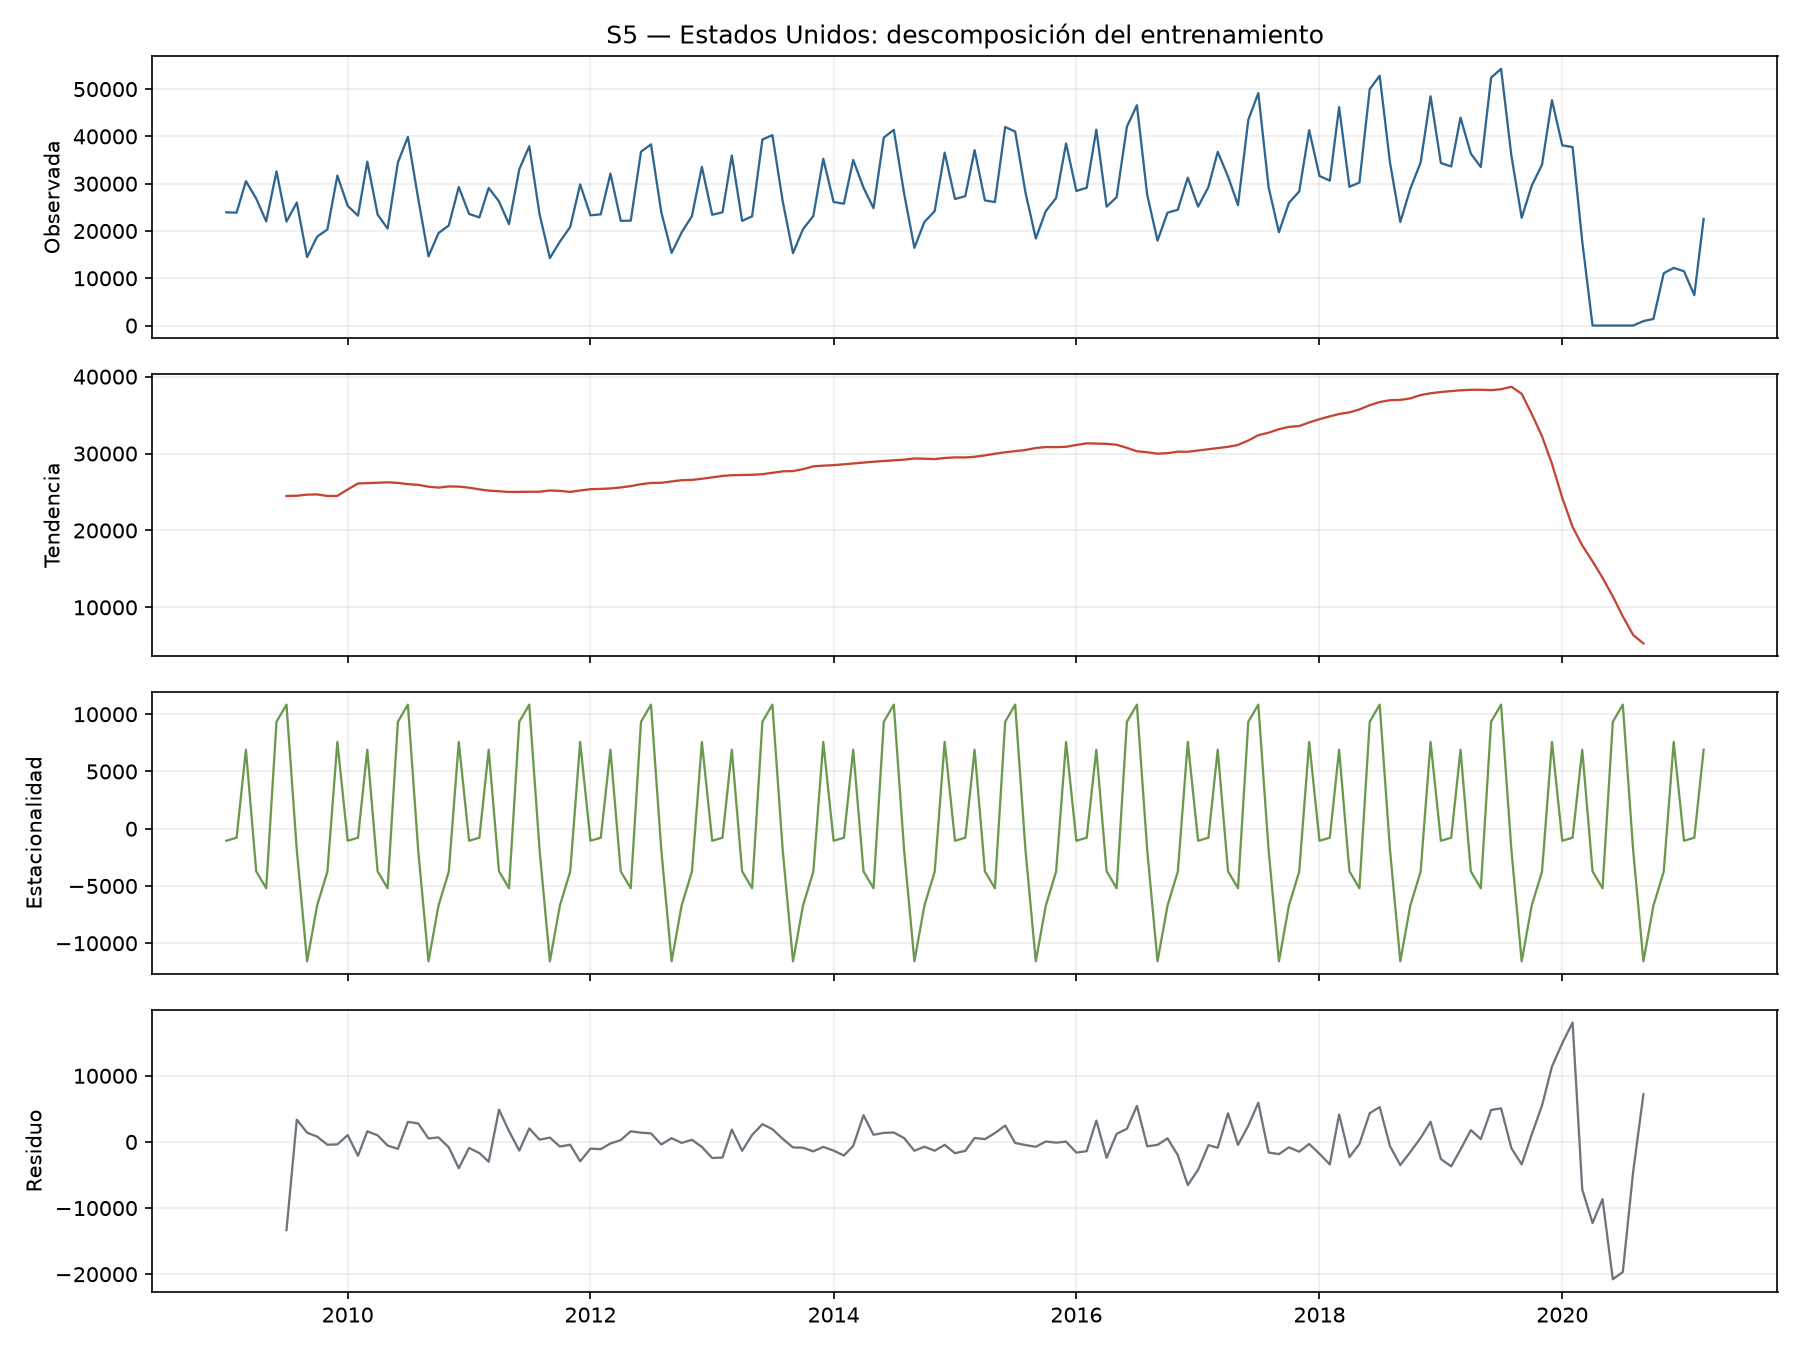

In [9]:
display(Image(filename=str(DIR_IMG / "s5_descomposicion.png")))

### `log1p` permite conservar los meses en cero

La transformación elegida se comporta como un logaritmo para valores grandes,
pero admite cero. Esto evita borrar o reemplazar los meses del cierre
pandémico. La decisión es metodológica: esos ceros son observaciones relevantes
del fenómeno y no datos faltantes.

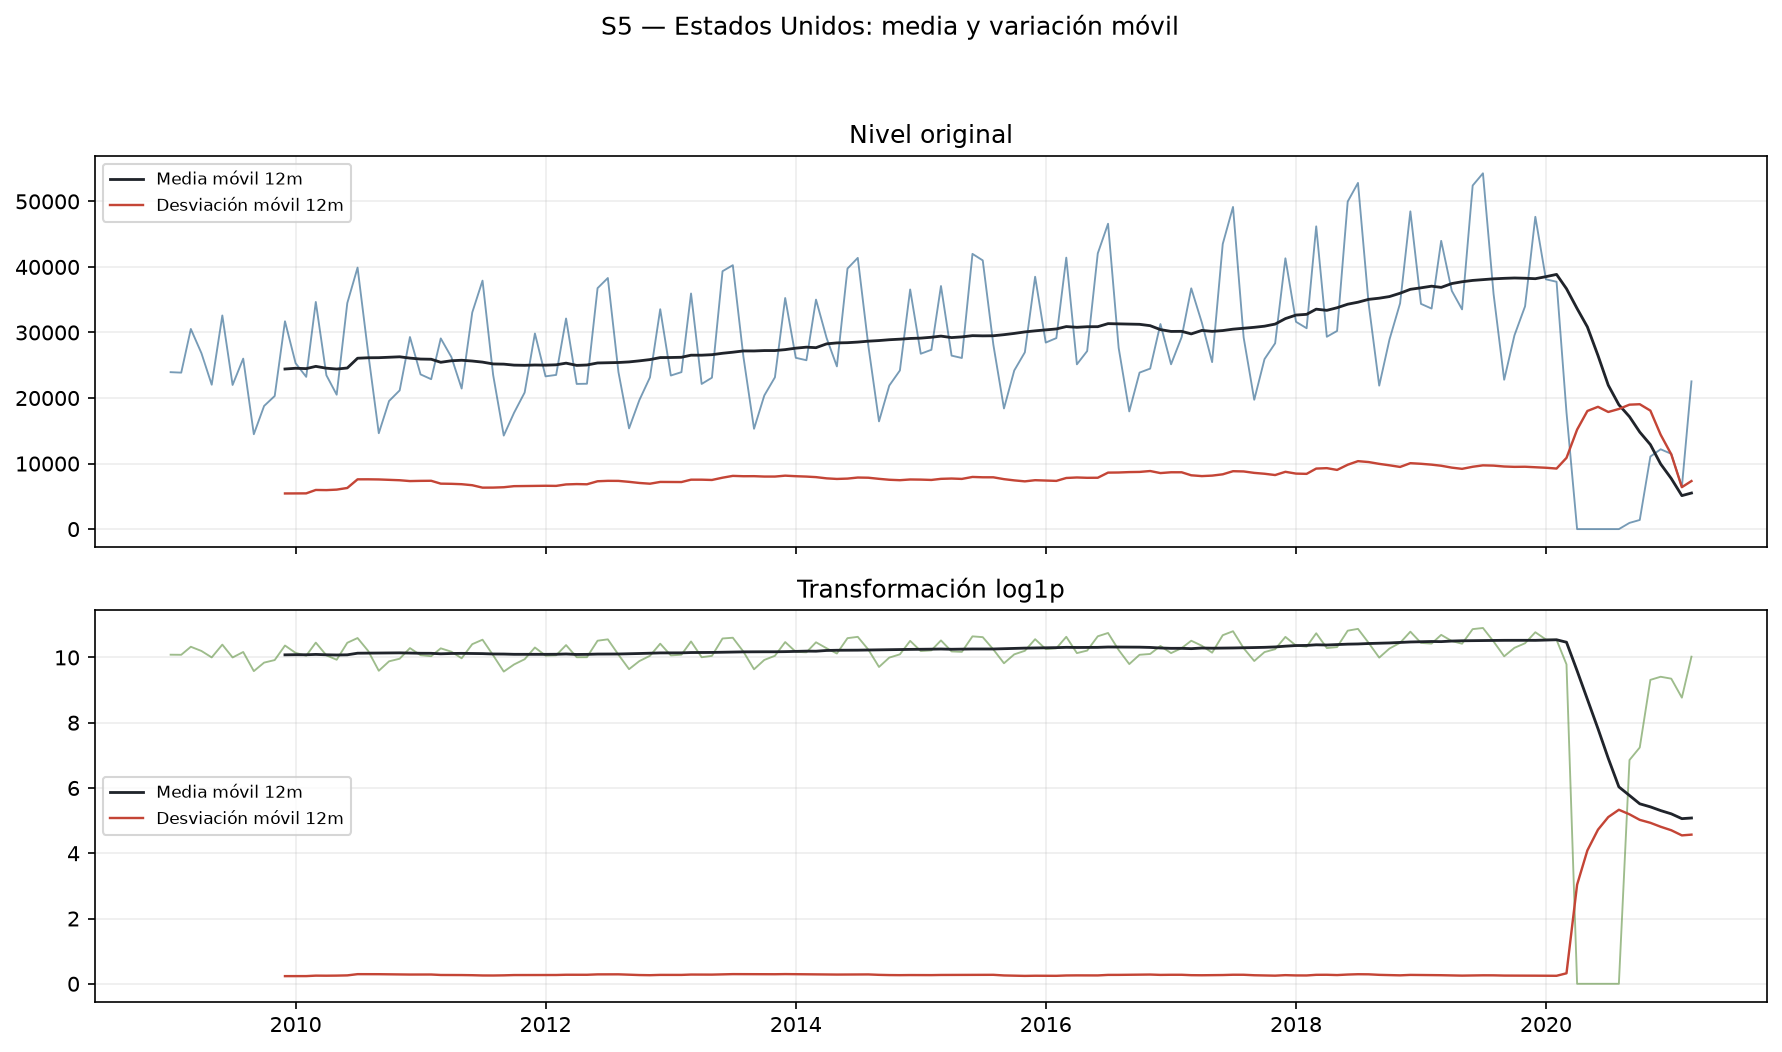

In [10]:
display(Image(filename=str(DIR_IMG / "s5_varianza.png")))

### La diferencia regular estabiliza la transformación

En `log1p` sin diferenciar, ADF y KPSS producen una lectura mixta. Después de
`d=1`, ambas pruebas apoyan estacionariedad. La diferencia estacional se prueba
en los candidatos SARIMA porque la ACF/PACF todavía muestra señales anuales,
pero se compara contra modelos sin `D=1` para evitar sobrediferenciar.

,transformacion,p_ADF,p_KPSS,veredicto
5,Nivel,0.0208,0.1000,estacionaria (ambas pruebas coinciden)
6,log1p,0.0821,0.1000,"resultado mixto: KPSS dice estacionaria, ADF no"
7,log1p + d=1,0.0487,0.1000,estacionaria (ambas pruebas coinciden)
8,log1p + D=1,0.9286,0.0616,"resultado mixto: KPSS dice estacionaria, ADF no"
9,log1p + d=1 + D=1,0.0000,0.1000,estacionaria (ambas pruebas coinciden)


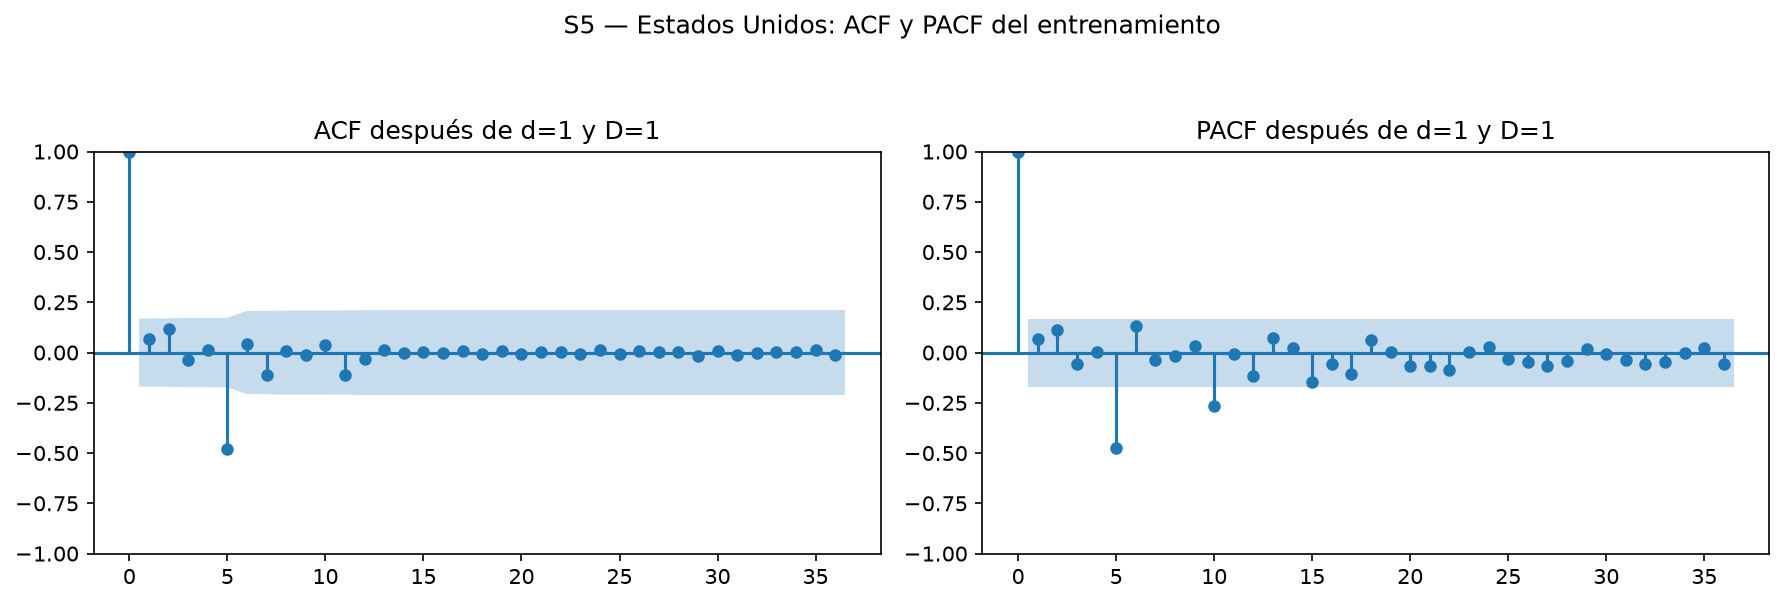

In [11]:
display(
    estacionariedad.loc[
        estacionariedad["serie"] == "S5_estados_unidos",
        ["transformacion", "p_ADF", "p_KPSS", "veredicto"],
    ].round(4)
)
display(Image(filename=str(DIR_IMG / "s5_acf_pacf.png")))

### ARIMA(1,1,1) es el menos impreciso, no un pronóstico suficiente

ARIMA(1,1,1) obtiene MAE de 22,975 y RMSE de
26,794 viajeros, con MAPE de
47.1%. Sus residuos todavía muestran autocorrelación en el
diagnóstico resumido (Ljung-Box p≈0.001) y el modelo sigue subestimando
el nivel posterior a 2022. Por eso se considera el menos impreciso de los
candidatos, pero no un modelo completamente adecuado.

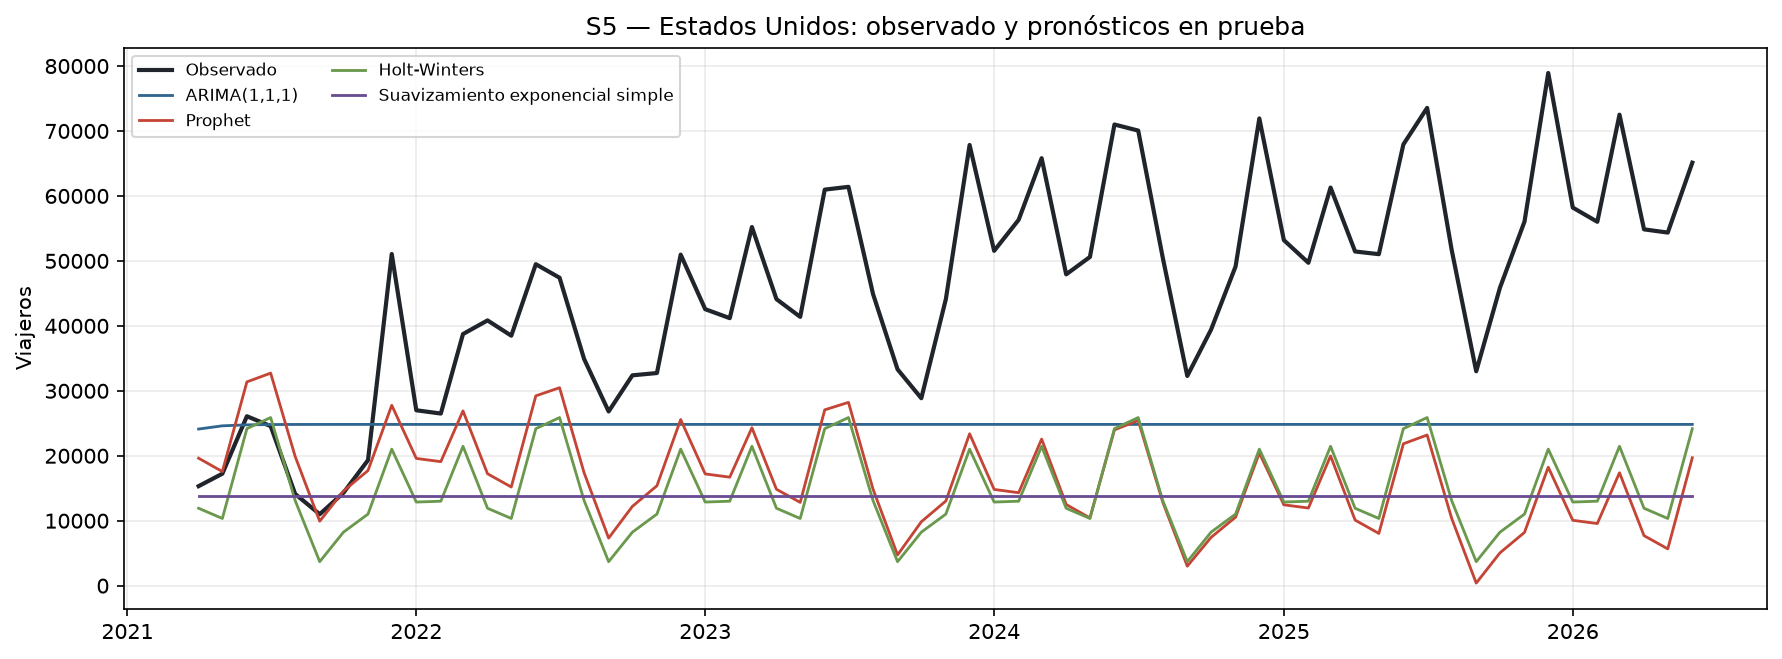

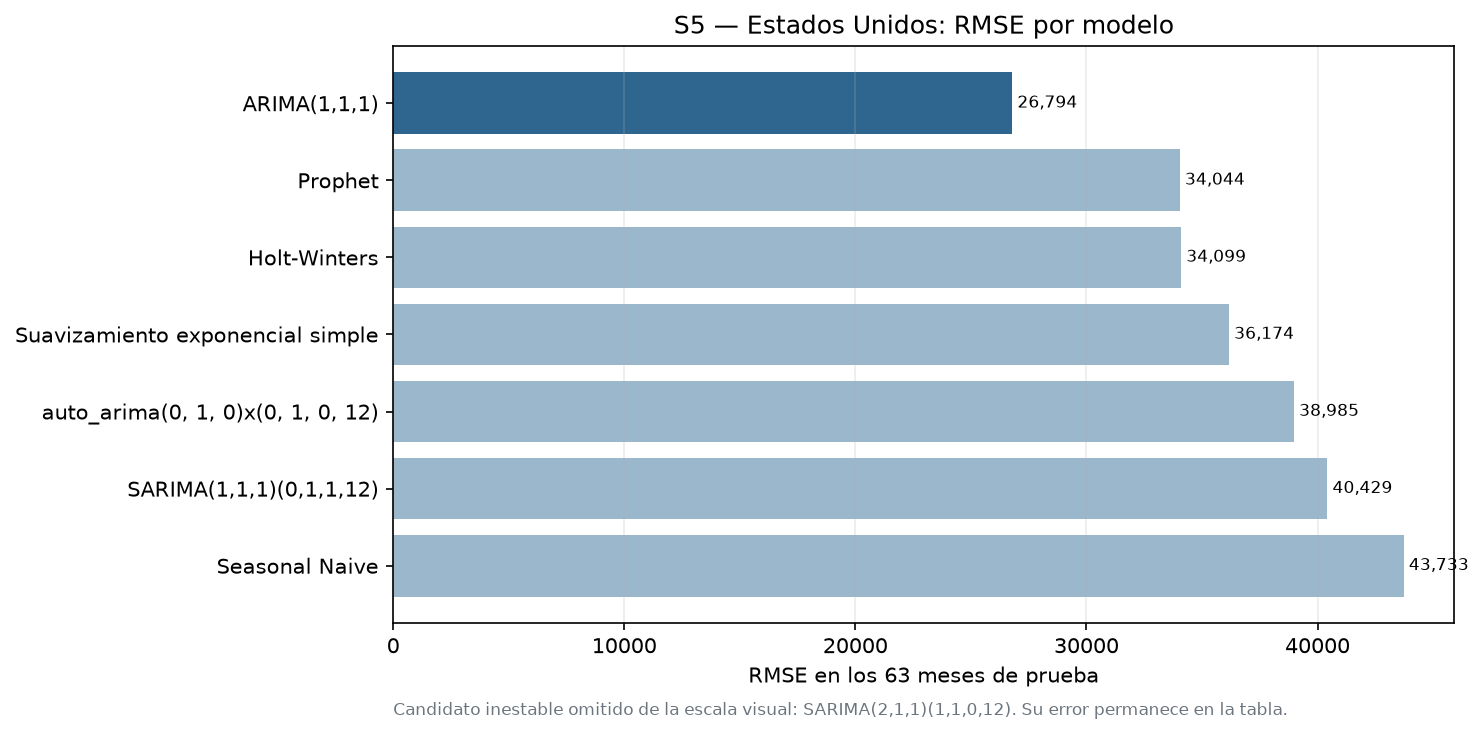

,serie,modelo,parametros,transformacion,AIC,BIC,MAE,RMSE,MAPE,Ljung_Box_p,mejor_modelo
8,S5_estados_unidos,"ARIMA(1,1,1)","{'orden': (1, 1, 1), 'orden_estacional': (0, 0...",log1p,431.91,440.82,2.297483e+04,2.679352e+04,4.708000e+01,0.0015,True
9,S5_estados_unidos,Prophet,"{'estacionalidad_anual': True, 'modo_estaciona...",ninguna,NaN,NaN,3.036167e+04,3.404367e+04,6.131000e+01,0.0000,False
10,S5_estados_unidos,Holt-Winters,"{'tendencia': 'aditiva amortiguada', 'estacion...",ninguna,NaN,NaN,3.125536e+04,3.409943e+04,6.524000e+01,0.4530,False
11,S5_estados_unidos,Suavizamiento exponencial simple,"{'tendencia': None, 'estacionalidad': None}",ninguna,NaN,NaN,3.230175e+04,3.617408e+04,6.428000e+01,0.0000,False
12,S5_estados_unidos,"auto_arima(0, 1, 0)x(0, 1, 0, 12)","{'orden': (0, 1, 0), 'orden_estacional': (0, 1...",log1p,401.66,404.55,3.475498e+04,3.898474e+04,7.778000e+01,0.0001,False
13,S5_estados_unidos,"SARIMA(1,1,1)(0,1,1,12)","{'orden': (1, 1, 1), 'orden_estacional': (0, 1...",log1p,376.88,388.03,3.670926e+04,4.042945e+04,7.886000e+01,0.0002,False
14,S5_estados_unidos,Seasonal Naive,{'rezago': 12},ninguna,NaN,NaN,4.073335e+04,4.373336e+04,8.869000e+01,0.0000,False
15,S5_estados_unidos,"SARIMA(2,1,1)(1,1,0,12)","{'orden': (2, 1, 1), 'orden_estacional': (1, 1...",log1p,366.87,380.80,2.272967e+14,1.354351e+15,3.347197e+11,0.0031,False


In [12]:
display(Image(filename=str(DIR_IMG / "s5_pronosticos.png")))
display(Image(filename=str(DIR_IMG / "s5_rmse_modelos.png")))
display(
    metricas.loc[metricas["serie"] == "S5_estados_unidos"].round({
        "AIC": 2, "BIC": 2, "MAE": 2, "RMSE": 2,
        "MAPE": 2, "Ljung_Box_p": 4,
    })
)

### Un AIC menor no garantizó un pronóstico estable

Uno de los SARIMA presentó AIC y BIC competitivos dentro del entrenamiento,
pero produjo pronósticos explosivos en la escala original. Se conserva en la
tabla como candidato descartado y se omite de la escala de la figura para que
los demás modelos puedan compararse. Este caso confirma que AIC/BIC deben
revisarse junto con los residuos y el error en prueba.

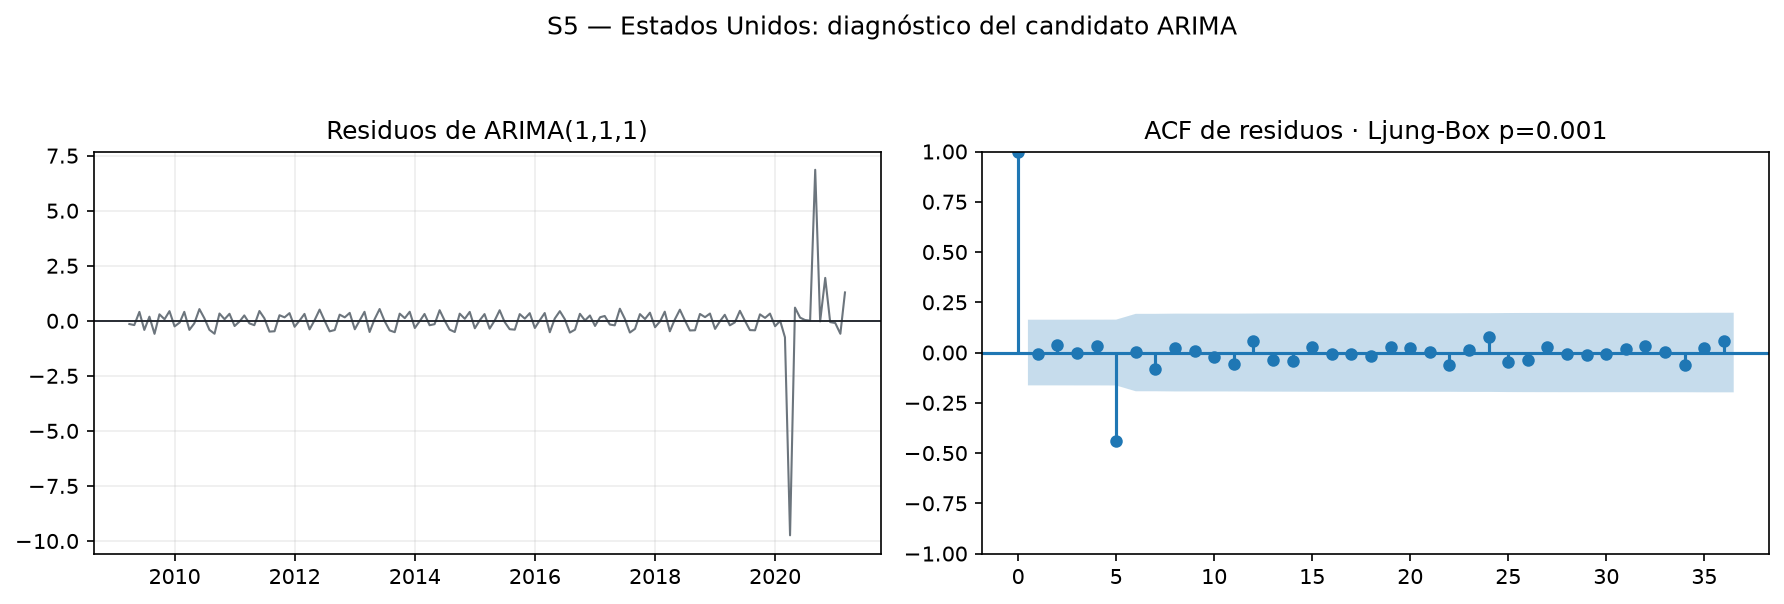

In [13]:
display(Image(filename=str(DIR_IMG / "s5_residuos.png")))

## Conclusiones y siguientes pasos

- La partición oficial evalúa los modelos durante una recuperación que no
  estaba representada plenamente en entrenamiento; por eso los errores son
  altos y la subestimación es general.
- S0 conserva más fuerza de tendencia que de estacionalidad. Prophet es el
  candidato con menor RMSE, aunque sus residuos indican estructura pendiente.
- S5 presenta tendencia y estacionalidad fuertes. ARIMA(1,1,1) es el mejor de
  los candidatos probados y supera la prueba de Ljung-Box, pero todavía queda
  lejos del nuevo nivel observado.
- La comparación entre AIC/BIC y RMSE muestra que un buen ajuste interno no
  garantiza un buen pronóstico cuando existe un cambio estructural.
- Cuando B y C entreguen sus módulos compartidos, deben sustituirse las
  implementaciones autónomas de Prophet y suavizamientos y comprobar que el
  formato y los resultados se mantengan.